In [1]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 3.5 MB/s eta 0:00:00


In [2]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

print("OSMnx version:", ox.__version__)

OSMnx version: 2.1.1


In [3]:
place_name = "City of Westminster, London, United Kingdom"

G_test = ox.graph_from_place(
    place_name,
    network_type="drive",
    simplify=True
)

print(G_test)

MultiDiGraph with 3381 nodes and 7616 edges


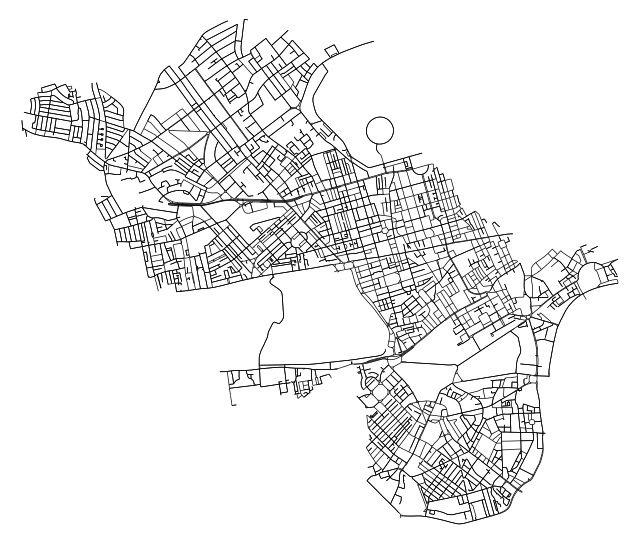

In [4]:
fig, ax = ox.plot_graph(
    G_test,
    node_size=0,
    edge_color="black",
    edge_linewidth=0.5,
    bgcolor="white"
)

In [5]:
nodes, edges = ox.graph_to_gdfs(G_test)

print("Number of nodes:", len(nodes))
print("Number of edges:", len(edges))

Number of nodes: 3381
Number of edges: 7616


In [6]:
nodes.head()

,y,x,street_count,highway,junction,geometry
osmid,,,,,,
99936,51.523627,-0.152799,4,NaN,NaN,POINT (-0.1528 51.52363)
99937,51.523018,-0.152024,3,NaN,NaN,POINT (-0.15202 51.52302)
101842,51.534056,-0.162652,3,NaN,NaN,POINT (-0.16265 51.53406)
101843,51.534945,-0.163664,4,NaN,NaN,POINT (-0.16366 51.53494)
101851,51.534512,-0.164451,3,NaN,NaN,POINT (-0.16445 51.53451)


In [7]:
edges.head()

osmid      access       highway  \
u     v          key                                                      
99936 2146383887 0                  204647020  permissive  unclassified   
      2146383892 0                  204647016  permissive   residential   
      4544836433 0    [233623258, 1303266759]  permissive  unclassified   
99937 25470798   0                   18769878         NaN         trunk   
      200047     0      [1067121866, 4257261]         NaN  unclassified   

                     maxspeed               name  oneway reversed     length  \
u     v          key                                                           
99936 2146383887 0     20 mph  York Terrace East   False    False   8.343876   
      2146383892 0     20 mph  York Terrace West   False     True  15.530363   
      4544836433 0     20 mph          York Gate    True    False  46.232763   
99937 25470798   0     20 mph    Marylebone Road    True    False  89.618143   
      200047     0     20 mph          York Gate    True    False  39.739273   

                                                               geometry lanes  \
u     v          key                                                            
99936 2146383887 0     LINESTRING (-0.1528 51.52363, -0.15268 51.52363)   NaN   
      2146383892 0    LINESTRING (-0.1528 51.52363, -0.15286 51.5236...   NaN   
      4544836433 0    LINESTRING (-0.1528 51.52363, -0.15291 51.5238...     2   
99937 25470798   0    LINESTRING (-0.15202 51.52302, -0.15221 51.523...     3   
      200047     0    LINESTRING (-0.15202 51.52302, -0.15232 51.523...   NaN   

                       ref bridge junction width est_width tunnel service  
u     v          key                                                       
99936 2146383887 0     NaN    NaN      NaN   NaN       NaN    NaN     NaN  
      2146383892 0     NaN    NaN      NaN   NaN       NaN    NaN     NaN  
      4544836433 0     NaN    NaN      NaN   NaN       NaN    NaN     NaN  
99937 25470798   0    A501    NaN      NaN   NaN       NaN    NaN     NaN  
      200047     0     NaN    NaN      NaN   NaN       NaN    NaN     NaN

In [8]:
place_name = "Greater London, England, United Kingdom"

G_london = ox.graph_from_place(
    place_name,
    network_type="drive",
    simplify=True
)

print(G_london)

MultiDiGraph with 130838 nodes and 304416 edges


In [9]:
nodes_london, edges_london = ox.graph_to_gdfs(G_london)

print("London nodes:", len(nodes_london))
print("London edges:", len(edges_london))

London nodes: 130838
London edges: 304416


In [10]:
edges_london.head()

osmid      access       highway maxspeed  \
u     v          key                                                 
78112 25508583   0    129375498  permissive  unclassified   20 mph   
      25508584   0    129375498  permissive  unclassified   20 mph   
                 1      4257258  permissive   residential   20 mph   
99936 2146383887 0    204647020  permissive  unclassified   20 mph   
      2146383892 0    204647016  permissive   residential   20 mph   

                                   name  oneway reversed      length  \
u     v          key                                                   
78112 25508583   0         Outer Circle   False    False   19.391301   
      25508584   0         Outer Circle   False     True   63.692568   
                 1    Cambridge Terrace    True    False  101.911328   
99936 2146383887 0    York Terrace East   False    False    8.343876   
      2146383892 0    York Terrace West   False     True   15.530363   

                                                               geometry lanes  \
u     v          key                                                            
78112 25508583   0     LINESTRING (-0.14579 51.52698, -0.14578 51.5268)   NaN   
      25508584   0    LINESTRING (-0.14579 51.52698, -0.14579 51.52755)   NaN   
                 1    LINESTRING (-0.14579 51.52698, -0.14567 51.526...   NaN   
99936 2146383887 0     LINESTRING (-0.1528 51.52363, -0.15268 51.52363)   NaN   
      2146383892 0    LINESTRING (-0.1528 51.52363, -0.15286 51.5236...   NaN   

                      ref bridge junction width tunnel est_width service area  
u     v          key                                                           
78112 25508583   0    NaN    NaN      NaN   NaN    NaN       NaN     NaN  NaN  
      25508584   0    NaN    NaN      NaN   NaN    NaN       NaN     NaN  NaN  
                 1    NaN    NaN      NaN   NaN    NaN       NaN     NaN  NaN  
99936 2146383887 0    NaN    NaN      NaN   NaN    NaN       NaN     NaN  NaN  
      2146383892 0    NaN    NaN      NaN   NaN    NaN       NaN     NaN  NaN

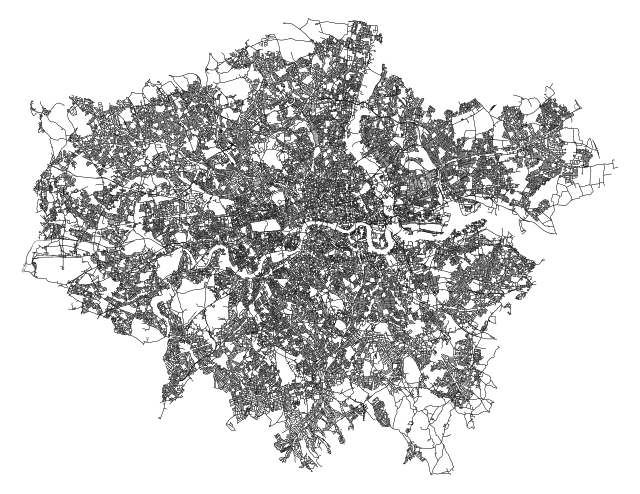

In [11]:
fig, ax = ox.plot_graph(
    G_london,
    node_size=0,
    edge_color="black",
    edge_linewidth=0.2,
    bgcolor="white"
)

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
import os

base_path = "/content/drive/MyDrive/london_collision_thesis"

folders = [
    "data/raw/osm",
    "data/raw/stats19",
    "data/raw/dft",
    "data/interim",
    "data/processed",
    "outputs/figures",
    "outputs/tables"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Folders created.")

Folders created.


In [15]:
graph_path = (
    "/content/drive/MyDrive/london_collision_thesis/"
    "data/raw/osm/greater_london_drive.graphml"
)

ox.save_graphml(G_london, filepath=graph_path)

print("Saved:", graph_path)

Saved: /content/drive/MyDrive/london_collision_thesis/data/raw/osm/greater_london_drive.graphml


In [16]:
G_london = ox.load_graphml(
    "/content/drive/MyDrive/london_collision_thesis/"
    "data/raw/osm/greater_london_drive.graphml"
)

In [17]:
edges_path = (
    "/content/drive/MyDrive/london_collision_thesis/"
    "data/raw/osm/greater_london_edges.gpkg"
)

edges_london.to_file(
    edges_path,
    driver="GPKG"
)

In [18]:
nodes_path = (
    "/content/drive/MyDrive/london_collision_thesis/"
    "data/raw/osm/greater_london_nodes.gpkg"
)

nodes_london.to_file(
    nodes_path,
    driver="GPKG"
)